# Instagram Engagement Analysis

**Key Focus Areas:**
- Engagement metrics (likes, comments, engagement rate)
- Like type and follower behavior
- Hashtag usage effectiveness
- User engagement concentration

## 1. Import Libraries

In [1]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Plot styling
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

## 2. Load Data and checking Null values

In [4]:
# Load datasets
comments = pd.read_csv('comments.csv')
followers = pd.read_csv('follows.csv')
likes = pd.read_csv('likes.csv')
photo_tags = pd.read_csv('photo_tags.csv')
photos = pd.read_csv('photos.csv')
tags = pd.read_csv('tags.csv')
users = pd.read_csv('users.csv')

print('Null values in comments', comments.isnull().sum().sum())
print('Null values in followers', followers.isnull().sum().sum())
print('Null values in likes', likes.isnull().sum().sum())
print('Null values in photo_tags', photo_tags .isnull().sum().sum())
print('Null values in photos', photos.isnull().sum().sum())
print('Null values in tags', tags .isnull().sum().sum())
print('Null values in users', users.isnull().sum().sum())

Null values in comments 0
Null values in followers 0
Null values in likes 0
Null values in photo_tags 0
Null values in photos 0
Null values in tags 0
Null values in users 0


## 3. Standardize Column Names

In [6]:
# Function to standardize column names
def clean_cols(df):
    df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
    return df

# Apply column cleaning to all datasets
comments = clean_cols(comments)
followers = clean_cols(followers)
likes = clean_cols(likes)
photo_tags = clean_cols(photo_tags)
photos = clean_cols(photos)
tags = clean_cols(tags)
users = clean_cols(users)

## 4. Engagement Metrics per Photo

In [7]:
# Count likes per photo
likes_count = likes.groupby('photo').size().reset_index(name='likes')

# Count comments per photo
comments_count = comments.groupby('photo_id').size().reset_index(name='comments')

# Merge engagement data with photos
photos_eng = (
    photos.merge(likes_count, left_on='id', right_on='photo', how='left')
          .merge(comments_count, left_on='id', right_on='photo_id', how='left')
)

# Fill missing values and compute total engagement
photos_eng[['likes', 'comments']] = photos_eng[['likes', 'comments']].fillna(0)
photos_eng['engagement'] = photos_eng['likes'] + photos_eng['comments']

photos_eng.head()

,id,image_link,user_id,created_dat,insta_filter_used,photo_type,photo,likes,photo_id,comments,engagement
0,1,http://elijah.biz,1,13-04-2023 08:04,yes,photo,1,25,1,25,50
1,2,https://shanon.org,1,13-04-2023 08:04,no,photo,2,36,2,31,67
2,3,http://vicky.biz,1,13-04-2023 08:04,no,photo,3,38,3,27,65
3,4,http://oleta.net,1,13-04-2023 08:04,no,photo,4,38,4,32,70
4,5,https://jennings.biz,1,13-04-2023 08:04,yes,photo,5,31,5,27,58


## 5. Engagement Rate Normalized by Followers

In [5]:
# Count followers per user
followers_count = followers.groupby('followee').size().reset_index(name='followers')

# Merge follower counts with engagement data
photos_eng = photos_eng.merge(
    followers_count,
    left_on='user_id',
    right_on='followee',
    how='left'
)

# Fill missing followers and calculate engagement rate
photos_eng['followers'] = photos_eng['followers'].fillna(0)
photos_eng['engagement_rate'] = np.where(
    photos_eng['followers'] > 0,
    photos_eng['engagement'] / photos_eng['followers'],
    0
)

# Summary statistics
photos_eng[['engagement', 'followers', 'engagement_rate']].describe()

,engagement,followers,engagement_rate
count,257.000000,257.000000,257.000000
mean,63.307393,76.307393,0.829693
std,4.810761,0.462314,0.063600
min,50.000000,76.000000,0.649351
25%,60.000000,76.000000,0.789474
50%,63.000000,76.000000,0.828947
75%,66.000000,77.000000,0.868421
max,79.000000,77.000000,1.039474


## 6. Engagement Composition (Likes vs Comments)

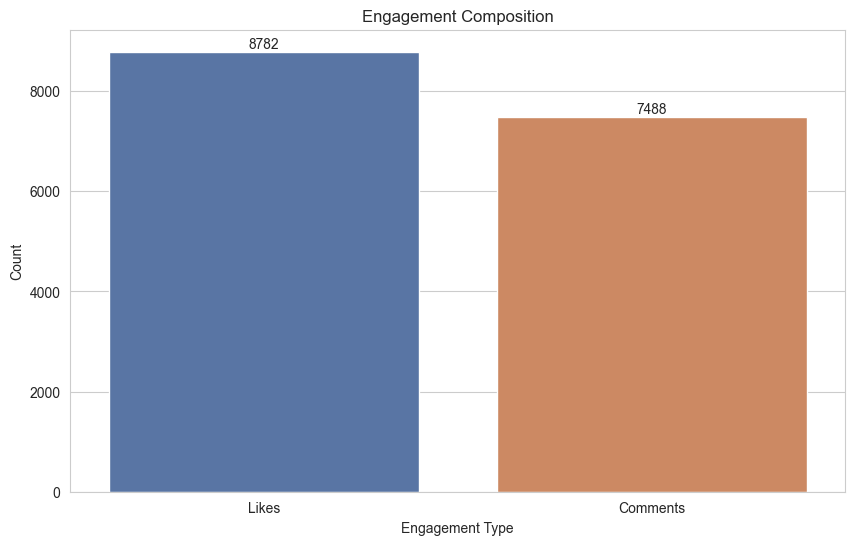

In [6]:
# Prepare engagement composition data
engagement_breakdown = pd.DataFrame({
    'Engagement Type': ['Likes', 'Comments'],
    'Count': [photos_eng['likes'].sum(), photos_eng['comments'].sum()]
})

# Plot likes vs comments
ax = sns.barplot(
    data=engagement_breakdown,
    x='Engagement Type',
    y='Count',
    palette=['#4C72B0', '#DD8452'],
    hue = 'Engagement Type'
)

# Add value labels
for c in ax.containers:
    ax.bar_label(c)

plt.title("Engagement Composition")
plt.show()

## 7. Like Type Distribution

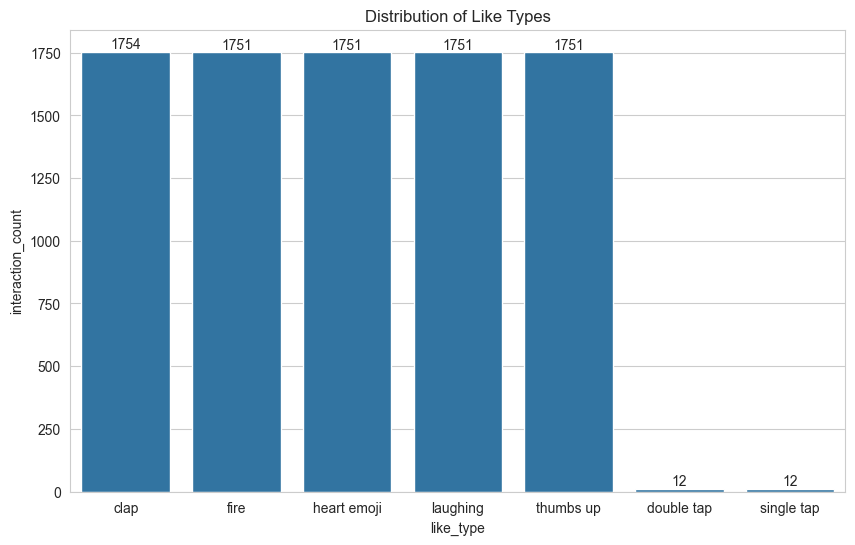

In [7]:
# Count interactions by like type
like_type_counts = (
    likes.groupby('like_type')
    .size()
    .reset_index(name='interaction_count')
    .sort_values('interaction_count', ascending=False)
)

# Plot like type distribution
ax = sns.barplot(
    data=like_type_counts,
    x='like_type',
    y='interaction_count'
)

# Add value labels
for c in ax.containers:
    ax.bar_label(c)

plt.title("Distribution of Like Types")
plt.show()

## 8. Hashtag Usage Analysis

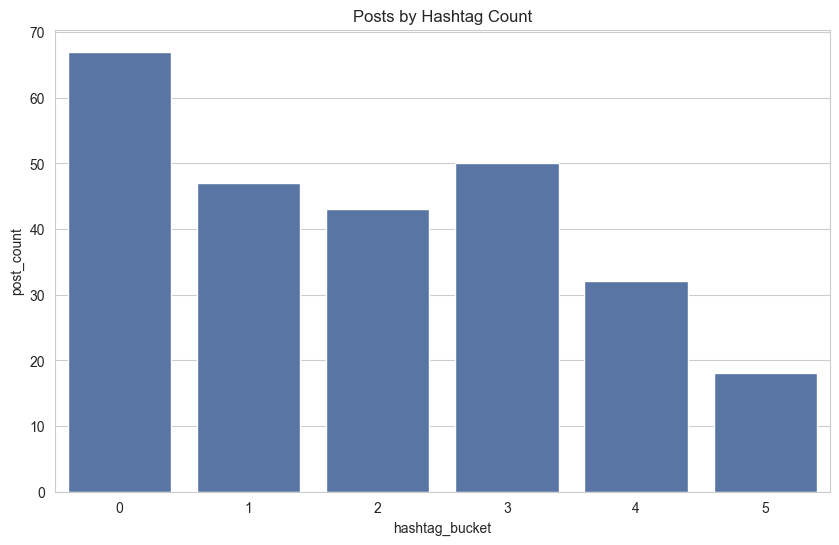

In [8]:
# Count hashtags per photo
tag_count = photo_tags.groupby('photo').size().reset_index(name='hashtag_count')

# Merge hashtag counts into engagement data
photos_eng = photos_eng.merge(
    tag_count,
    left_on='id',
    right_on='photo',
    how='left'
)

# Fill missing hashtag counts
photos_eng['hashtag_count'] = photos_eng['hashtag_count'].fillna(0)

# Create hashtag count buckets (0–5)
photos_eng['hashtag_bucket'] = pd.cut(
    photos_eng['hashtag_count'],
    bins=[-1, 0, 1, 2, 3, 4, 5],
    labels=['0', '1', '2', '3', '4', '5']
)

# Count posts per hashtag bucket
bucket_counts = (
    photos_eng
    .groupby('hashtag_bucket', observed=True)
    .size()
    .reset_index(name='post_count')
)

# Plot hashtag usage distribution
sns.barplot(
    data=bucket_counts,
    x='hashtag_bucket',
    y='post_count',
    color='#4C72B0'
)

plt.title("Posts by Hashtag Count")
plt.show()

## 9. Top Hashtags Used

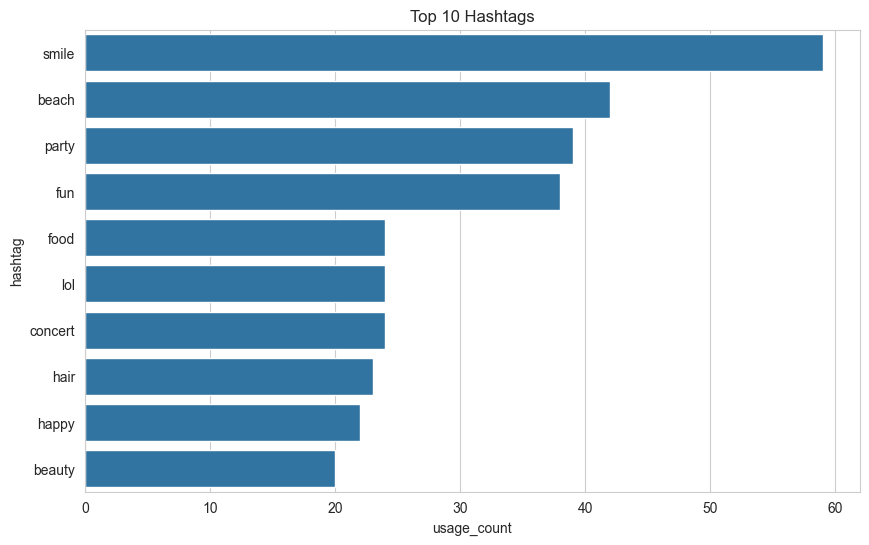

In [9]:
# Merge photo–tag mapping with tag details
photo_tags_full = photo_tags.merge(tags, left_on='tag_id', right_on='id')

# Identify top 10 most used hashtags
top_tags = (
    photo_tags_full['tag_text']
    .value_counts()
    .head(10)
    .reset_index()
)

top_tags.columns = ['hashtag', 'usage_count']

# Plot top hashtags
sns.barplot(
    data=top_tags,
    x='usage_count',
    y='hashtag'
)

plt.title("Top 10 Hashtags")
plt.show()

## 10. Top Engaged Users

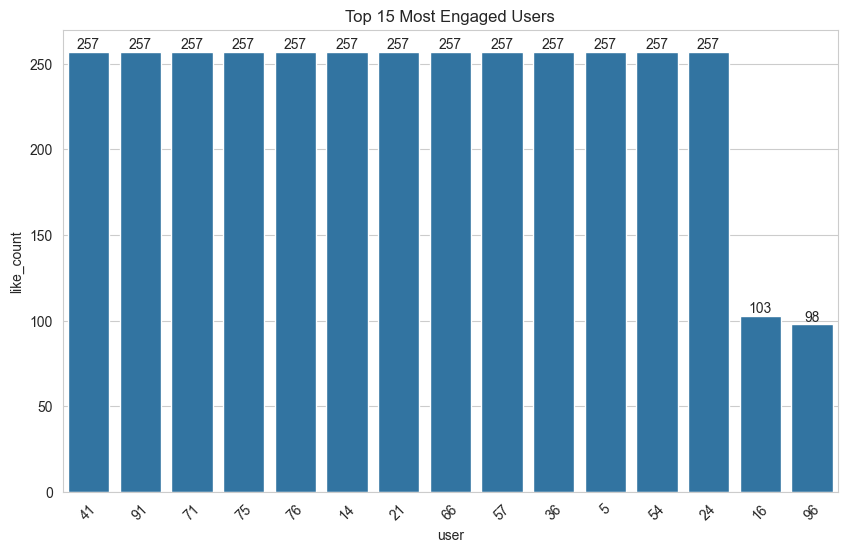

In [10]:
# Identify top 15 users by number of likes
top_users = (
    likes.groupby('user')
    .size()
    .reset_index(name='like_count')
    .sort_values('like_count', ascending=False)
    .head(15)
)

# Preserve order for plotting
top_users['user'] = pd.Categorical(
    top_users['user'],
    categories=top_users['user'],
    ordered=True
)

# Plot top engaged users
ax = sns.barplot(
    data=top_users,
    x='user',
    y='like_count'
)

# Add value labels
for c in ax.containers:
    ax.bar_label(c)

plt.title("Top 15 Most Engaged Users")
plt.xticks(rotation=45)
plt.show()

## 11. Key Public and Private Account Percentage

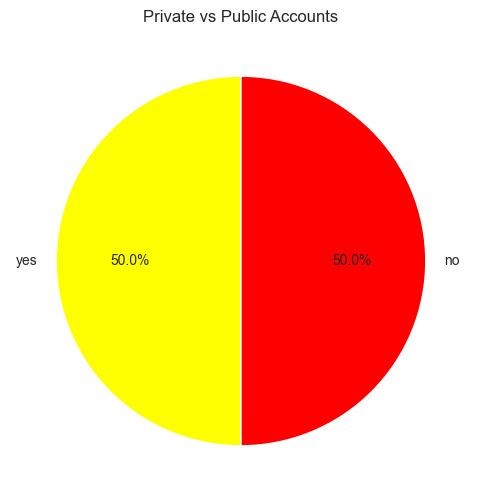

In [11]:
# Count private vs public accounts
account_type_counts = users['private/public'].value_counts()

# Plot pie chart
plt.pie(
    account_type_counts,
    labels=account_type_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=['yellow', 'red']
)

plt.title("Private vs Public Accounts")
plt.show()

## 12. Key Insights & Recommendations

## Recommended Content Calendar & Engagement Strategy

### Optimal Content Calendar
Based on engagement patterns normalized by follower count, the focus should be on **content quality and consistency** rather than posting time.

- **Posting Frequency:** 4–5 posts per week  
- **Content Mix:** Educational posts, tutorials, and product insights  
- **Formats:** High-performing photo types and carousel-style content  
- **Hashtags:** 5–10 relevant and niche hashtags per post  

### 5 Strategies to Increase Engagement

1. **Prioritize High-Engagement Content Types**  
   Focus on photo formats that generate higher likes and comments per follower.

2. **Optimize for Non-Follower Reach**  
   Create shareable and informative content to convert non-followers into followers.

3. **Normalize Engagement Metrics**  
   Track likes and comments per follower to evaluate content performance fairly.

4. **Encourage Active Interaction**  
   Use clear CTAs (questions, polls, prompts) to increase comments over passive likes.

5. **Maintain Consistent Posting**  
   A steady posting schedule builds audience familiarity and sustained engagement.